In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

# Imports

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import pandas as pd
import geopandas as gpd
import contextily as ctx
import pandas as pd
import os

import sys
import os

from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *

os.chdir('/home/sandbox/personal-repos/DA-3507/dump')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../lib')))
from custom_pandas import *

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


## Get the surveys

In [3]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])

In [4]:
query = f"""SELECT RA.Shape.STAsText() AS SurveyArea,
    RA.ReportId
FROM ReportArea RA
WHERE RA.ReportId IN (SELECT ReportId FROM #TempReport)"""
report_bc = a.iloc[[-1]].copy()
report_bc

,CustomerName,ReportName,ReportId,ReportTitle,Label,ReportDate,BoundaryName,BoundaryType,ReportAssetLengthKm,ReportPercentCoverageAssets,...,DistributionPipeCoveredKm,DistributionPipePercentCovered,ServicePipeKm,ServicePipeCoveredKm,AreaKM2,AreaCoveredKM2,ReportYear,ReportMonth,ReportWeek,ReportQuarter
1079,Cadent,CR-EFE1AD,EFE1AD40-D740-0F8B-759D-3A2092B7319F,B26 - 8331 - Birmingham - Bromsgrove - Lickey ...,Final Checkbox,2026-04-12 07:14:03.807,B26 - 8331 - Birmingham - Bromsgrove - Lickey ...,--Select--,16.002268,0.796873,...,12.42181,0.821926,0.889213,0.329971,2.678674,0.479035,2026,4,16,2


In [5]:
report_bc.db.set_query(query_SurveyH3Aggregation_byReport(report_table = '#TempReport'))
data =report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
report_bc.db.set_query(query)
boundary = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

In [6]:
merged = pd.merge(data, boundary, on="ReportId")
merged.drop(columns=["ReportId"])
merged.BreadcrumbCounts.set_H3Resolution(11)
merged.BreadcrumbCounts.set_counts_only(False)
a = merged.BreadcrumbCounts.calculate('Breadcrumb','SurveyArea')
a['Passes'] = a['Intersections'] / 2

In [7]:
result = a.groupby("h3_cell").agg({"Passes": "sum", "SurveyId": "first"}).reset_index()

In [8]:
result.describe()

,Passes
count,245.000000
mean,5.651020
std,2.603522
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,16.000000


In [9]:
result['Passes'].mode()

0    6.0
Name: Passes, dtype: float64

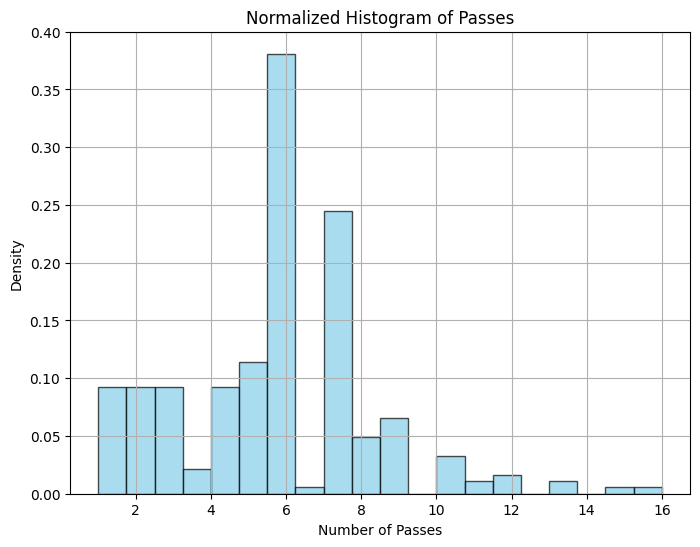

In [12]:
# INSERT_YOUR_CODE
import matplotlib.pyplot as plt

# Plot a normalized histogram of the 'Passes' column
plt.figure(figsize=(8, 6))
plt.hist(result['Passes'], bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Number of Passes')
plt.ylabel('Density')
plt.title('Normalized Histogram of Passes')
plt.grid(True)
plt.show()

/tmp/ipykernel_42105/1212336226.py:57: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


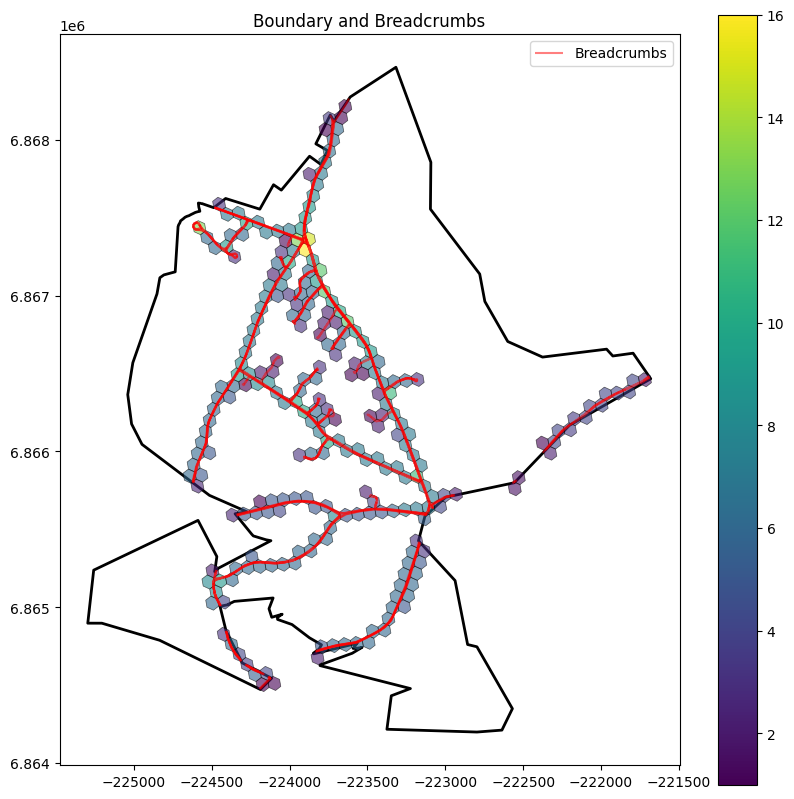

In [14]:
# INSERT_YOUR_CODE

import matplotlib.pyplot as plt

import contextily as ctx

# Plot the boundary
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the SurveyArea (boundary), should be a single row in 'boundary'
boundary_gdf = boundary.copy()
boundary_gdf['geometry'] = boundary_gdf['SurveyArea'].apply(lambda x: wkt.loads(x))
boundary_gdf = gpd.GeoDataFrame(boundary_gdf, geometry='geometry', crs='EPSG:4326')
boundary_gdf = boundary_gdf.to_crs(epsg=3857)
boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, label='Boundary')

# Plot the Breadcrumbs
data_gdf = data.copy()
data_gdf['geometry'] = data_gdf['Breadcrumb'].apply(lambda x: wkt.loads(x))
data_gdf = gpd.GeoDataFrame(data_gdf, geometry='geometry', crs='EPSG:4326')
data_gdf = data_gdf.to_crs(epsg=3857)
data_gdf.plot(ax=ax, color='red', alpha=0.5, label='Breadcrumbs')

# INSERT_YOUR_CODE

# Plot the H3 hexagons with Intersections
from shapely.geometry import Polygon

def h3_cell_polygon(cell):
    # Returns a shapely Polygon for an h3 cell index
    boundary = h3.cell_to_boundary(cell)
    # The boundary comes as list of (lat, lng) tuples, so convert to (x, y) = (lng, lat)
    return Polygon([(lng, lat) for lat, lng in boundary])

# Create GeoDataFrame for hexagons with intersection counts
result_hex = result.copy()
result_hex['geometry'] = result_hex['h3_cell'].apply(h3_cell_polygon)
hex_gdf = gpd.GeoDataFrame(result_hex, geometry='geometry', crs="EPSG:4326")
hex_gdf = hex_gdf.to_crs(epsg=3857)

# Plot the hexagons with Intersections as the color (using a colormap)
hex_gdf.plot(
    ax=ax,
    column="Passes",
    alpha=0.6,
    edgecolor='k',
    linewidth=0.5,
    legend=True,
    label="H3 Hexagons"
)


# Add a base map using contextily
#ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap, crs="EPSG:3857")

ax.set_title("Boundary and Breadcrumbs")
ax.legend()
plt.show()

In [15]:
# INSERT_YOUR_CODE

import folium
from folium import features
import geopandas as gpd
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

# Project all geodata back to EPSG:4326 for folium (Web Mercator tiles will convert as needed)
boundary_gdf_4326 = boundary_gdf.to_crs(epsg=4326)
data_gdf_4326 = data_gdf.to_crs(epsg=4326)
hex_gdf_4326 = hex_gdf.to_crs(epsg=4326)

# Get the centroid of the boundary for map starting position
if not boundary_gdf_4326.empty:
    center = boundary_gdf_4326.unary_union.centroid
    map_center = [center.y, center.x]
else:
    map_center = [0, 0]  # fallback

m = folium.Map(location=map_center, zoom_start=13, tiles='cartodbpositron')

# Add boundary as a GeoJson
folium.GeoJson(
    boundary_gdf_4326,
    style_function=lambda feature: {
        'color': 'black',
        'weight': 2,
        'fill': False,
    },
    name="Boundary"
).add_to(m)

# Add breadcrumbs as red points
for idx, row in data_gdf_4326.iterrows():
    geom = row['geometry']
    if geom.geom_type == "Point":
        folium.CircleMarker(
            location=[geom.y, geom.x],
            radius=2,
            color='red',
            fill=True,
            fill_opacity=0.5,
            popup=None,
        ).add_to(m)
    elif geom.geom_type in {"LineString", "MultiLineString"}:
        folium.GeoJson(
            row['geometry'],
            style_function=lambda x: {'color': 'red', 'weight': 2, 'opacity': 0.5},
            name='Breadcrumbs'
        ).add_to(m)

# Plot the hexagons colored by "Passes" count
if 'Passes' in hex_gdf_4326.columns:
    cmap = cm.get_cmap('viridis')
    passes_vals = hex_gdf_4326['Passes'].astype(float)
    # Create a colormap normalization
    norm = colors.Normalize(vmin=passes_vals.min(), vmax=passes_vals.max())
    # Add polygons to map
    for _, row in hex_gdf_4326.iterrows():
        poly = row['geometry']
        value = row['Passes']
        color_rgba = cmap(norm(value))
        color_hex = matplotlib.colors.rgb2hex(color_rgba)
        folium.GeoJson(
            poly,
            style_function=lambda feature, color=color_hex: {
                'fillColor': color,
                'color': 'black',
                'weight': 0.5,
                'fillOpacity': 0.6,
            },
            highlight_function=lambda x: {'weight':2, 'color':'yellow'}
        ).add_to(m)
    # Add a colorbar using branca if needed (optional)

# Add layer control and legend if desired
folium.LayerControl().add_to(m)

# Display the map in Jupyter
m

/tmp/ipykernel_42105/4099284816.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
